# TweetSense Sentiment Comparison

In this notebook we compare two methods:

1. **Traditional Machine Learning:** clean text, TF-IDF, then train ML classifiers.
2. **Local Hugging Face Model:** use a transformer zero-shot classifier.

Labels: `Positive`, `Negative`, `Neutral`, `Irrelevant`.

## 1. Import Libraries

In [2]:
import re
import string
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import TweetTokenizer

sns.set_theme(style="whitegrid")

## 2. Basic Settings

In [6]:
TRAIN_PATH = "/content/twitter_training.csv"
VALIDATION_PATH = "/content/twitter_validation.csv"

LABELS = ["Positive", "Negative", "Neutral", "Irrelevant"]
RANDOM_STATE = 42

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

print("Training file exists:", Path(TRAIN_PATH).exists())
print("Validation file exists:", Path(VALIDATION_PATH).exists())

Training file exists: True
Validation file exists: True


## 3. Download NLTK Resources

We use NLTK for stopwords, stemming, and lemmatization.

In [7]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 4. Load the Dataset

The dataset has four columns, so we give them clear names.

In [8]:
columns = ["tweet_id", "entity", "sentiment", "tweet"]

train_df = pd.read_csv(TRAIN_PATH, header=None, names=columns)
valid_df = pd.read_csv(VALIDATION_PATH, header=None, names=columns)

print("Training shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
train_df.head()

Training shape: (74682, 4)
Validation shape: (1000, 4)


,tweet_id,entity,sentiment,tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


## 5. Clean Missing Values and Labels

In [9]:
train_df = train_df.dropna(subset=["tweet", "sentiment"])
valid_df = valid_df.dropna(subset=["tweet", "sentiment"])

train_df = train_df[train_df["sentiment"].isin(LABELS)]
valid_df = valid_df[valid_df["sentiment"].isin(LABELS)]

print("Training labels")
display(train_df["sentiment"].value_counts())

print("Validation labels")
display(valid_df["sentiment"].value_counts())

Training labels


,count
sentiment,
Negative,22358
Positive,20655
Neutral,18108
Irrelevant,12875


Validation labels


,count
sentiment,
Neutral,285
Positive,277
Negative,266
Irrelevant,172


## 6. Text Preprocessing Function

This follows our pipeline:

Raw tweet -> remove noise -> lowercase -> tokenize -> remove stopwords -> stemming or lemmatization.

In [10]:
def clean_tweet(text, method="lemma"):
    text = str(text)

    # Remove URLs and mentions
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)

    # Remove only the hashtag symbol, but keep the word
    text = re.sub(r"#(\w+)", r"\1", text)

    # Remove emojis and non-English symbols
    text = text.encode("ascii", "ignore").decode("ascii")

    # Lowercase and remove punctuation
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Tokenize and remove stopwords
    tokens = tokenizer.tokenize(text)
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]

    # Normalize words
    if method == "stem":
        tokens = [stemmer.stem(word) for word in tokens]
    else:
        tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)


example = "I LOVE this update!!! 😍 https://example.com #Amazing @user"
print("Stemmed:", clean_tweet(example, method="stem"))
print("Lemmatized:", clean_tweet(example, method="lemma"))

Stemmed: love updat amaz
Lemmatized: love update amazing


## 7. Create Clean Text Columns

In [11]:
train_df["tweet_stem"] = train_df["tweet"].apply(lambda x: clean_tweet(x, method="stem"))
valid_df["tweet_stem"] = valid_df["tweet"].apply(lambda x: clean_tweet(x, method="stem"))

train_df["tweet_lemma"] = train_df["tweet"].apply(lambda x: clean_tweet(x, method="lemma"))
valid_df["tweet_lemma"] = valid_df["tweet"].apply(lambda x: clean_tweet(x, method="lemma"))

train_df[["tweet", "tweet_stem", "tweet_lemma"]].head()

,tweet,tweet_stem,tweet_lemma
0,im getting on borderlands and i will murder yo...,im get borderland murder,im getting borderland murder
1,I am coming to the borders and I will kill you...,come border kill,coming border kill
2,im getting on borderlands and i will kill you ...,im get borderland kill,im getting borderland kill
3,im coming on borderlands and i will murder you...,im come borderland murder,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im get borderland murder,im getting borderland murder


## 8. Train Traditional ML Models

We test three classifiers with both stemmed and lemmatized tweets.

In [18]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
    "Naive Bayes": MultinomialNB(),
}

text_versions = {
    "stem": ("tweet_stem", "Stemmed text"),
    "lemma": ("tweet_lemma", "Lemmatized text"),
}

traditional_results = []
saved_models = {}

for text_method, (text_column, text_name) in text_versions.items():
    X_train = train_df[text_column]
    X_valid = valid_df[text_column]
    y_train = train_df["sentiment"]
    y_valid = valid_df["sentiment"]

    for classifier_name, classifier in classifiers.items():
        model_name = f"{text_name} + {classifier_name}"
        print("Training:", model_name)

        model = Pipeline([
            ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95)),
            ("classifier", classifier),
        ])

        start_time = time.time()
        model.fit(X_train, y_train)
        predictions = model.predict(X_valid)
        runtime = time.time() - start_time

        traditional_results.append({
            "method": "Traditional TF-IDF",
            "model": model_name,
            "text_method": text_method,
            "accuracy": accuracy_score(y_valid, predictions),
            "macro_f1": f1_score(y_valid, predictions, labels=LABELS, average="macro"),
            "weighted_f1": f1_score(y_valid, predictions, labels=LABELS, average="weighted"),
            "runtime_seconds": runtime,
        })

        saved_models[model_name] = model

traditional_results_df = pd.DataFrame(traditional_results).sort_values("macro_f1", ascending=False)
traditional_results_df

Training: Stemmed text + Logistic Regression
Training: Stemmed text + Linear SVM
Training: Stemmed text + Naive Bayes
Training: Lemmatized text + Logistic Regression
Training: Lemmatized text + Linear SVM
Training: Lemmatized text + Naive Bayes


,method,model,text_method,accuracy,macro_f1,weighted_f1,runtime_seconds
1,Traditional TF-IDF,Stemmed text + Linear SVM,stem,0.983,0.981971,0.983046,6.906097
4,Traditional TF-IDF,Lemmatized text + Linear SVM,lemma,0.982,0.981282,0.982011,8.592476
3,Traditional TF-IDF,Lemmatized text + Logistic Regression,lemma,0.970,0.969666,0.970033,34.389878
0,Traditional TF-IDF,Stemmed text + Logistic Regression,stem,0.970,0.969128,0.970059,46.155892
2,Traditional TF-IDF,Stemmed text + Naive Bayes,stem,0.962,0.961265,0.962007,3.310800
5,Traditional TF-IDF,Lemmatized text + Naive Bayes,lemma,0.957,0.956822,0.957081,2.514900


In [1]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=traditional_results_df)

NameError: name 'traditional_results_df' is not defined

## 9. Evaluate and Save the Best Traditional Model

In [20]:
best_row = traditional_results_df.iloc[0]
best_model_name = best_row["model"]
best_text_method = best_row["text_method"]

# Extract classifier name from best_model_name, e.g., "Stemmed text + Linear SVM" -> "Linear SVM"
classifier_name_from_best_model = best_model_name.split(' + ')[1]
best_classifier = classifiers[classifier_name_from_best_model]

# Prepare training and validation data for the best text method
X_train_best = train_df[f"tweet_{best_text_method}"]
y_train_best = train_df["sentiment"]
valid_clean_text = valid_df[f"tweet_{best_text_method}"]
y_valid = valid_df["sentiment"]

print(f"Re-training the best model: {best_model_name}")

# Create a fresh pipeline for the best model
best_model_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95)),
    ("classifier", best_classifier),
])

# Fit the new pipeline
best_model_pipeline.fit(X_train_best, y_train_best)

# Make predictions using the newly fitted pipeline
traditional_predictions = best_model_pipeline.predict(valid_clean_text)

print("Best traditional model:", best_model_name)
print(classification_report(y_valid, traditional_predictions, labels=LABELS))

model_package = {
    "model": best_model_pipeline, # Save the newly fitted pipeline
    "text_method": best_text_method,
    "labels": LABELS,
}

model_path = MODEL_DIR / "tweetsense_tfidf_model.joblib"
joblib.dump(model_package, model_path)
print("Saved model package to:", model_path)

Re-training the best model: Stemmed text + Linear SVM
Best traditional model: Stemmed text + Linear SVM
              precision    recall  f1-score   support

    Positive       0.97      0.98      0.98       277
    Negative       1.00      0.98      0.99       266
     Neutral       0.99      0.98      0.99       285
  Irrelevant       0.96      0.98      0.97       172

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000

Saved model package to: models/tweetsense_tfidf_model.joblib


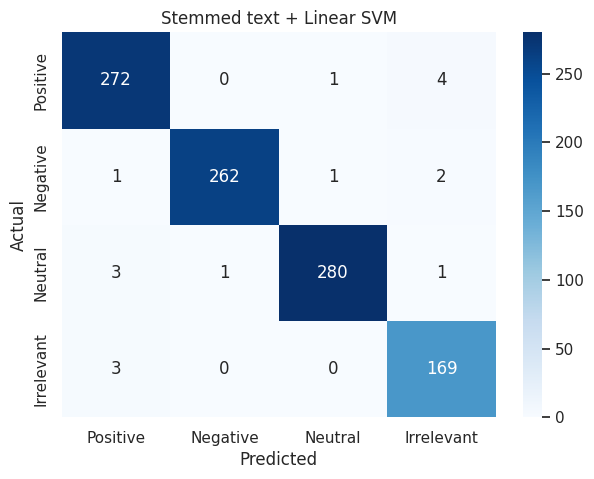

In [21]:
def show_confusion_matrix(y_true, y_pred, title):
    matrix = confusion_matrix(y_true, y_pred, labels=LABELS)

    plt.figure(figsize=(7, 5))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


show_confusion_matrix(valid_df["sentiment"], traditional_predictions, best_model_name)

## 10. Local Hugging Face Classification

We use a Hugging Face zero-shot model. This lets us classify tweets into our four labels without training a new neural network.

The first run may download the model. After it downloads, it runs locally from your computer cache.

In [22]:
from transformers import pipeline

HF_MODEL_NAME = "facebook/bart-large-mnli"
HF_SAMPLE_PER_CLASS = 5

hf_sample = (
    valid_df
    .groupby("sentiment", group_keys=False)
    .apply(lambda group: group.sample(min(len(group), HF_SAMPLE_PER_CLASS), random_state=RANDOM_STATE))
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print("Hugging Face sample size:", len(hf_sample))
hf_sample[["entity", "sentiment", "tweet"]].head()

Hugging Face sample size: 20


/tmp/ipykernel_10773/1448699833.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(min(len(group), HF_SAMPLE_PER_CLASS), random_state=RANDOM_STATE))


,entity,sentiment,tweet
0,Cyberpunk2077,Irrelevant,Very interesting read! I agree more women shou...
1,Xbox(Xseries),Positive,@Xbox @majornelson I’d love to bring home a ne...
2,Microsoft,Positive,#Indigo Urgent Care looks to Microsoft Teams a...
3,Google,Irrelevant,"This is my 143rd twitter account, I keep getti..."
4,Borderlands,Negative,"April 30 until now, for no apparent reason, BL..."


In [23]:
zero_shot_classifier = pipeline(
    "zero-shot-classification",
    model=HF_MODEL_NAME,
    device=-1,
)

def classify_with_hugging_face(tweet, entity):
    text = f"Tweet about {entity}: {tweet}"
    result = zero_shot_classifier(
        text,
        candidate_labels=LABELS,
        hypothesis_template="This tweet sentiment is {}.",
    )

    return result["labels"][0], result["scores"][0]


hf_predictions = []
hf_scores = []
start_time = time.time()

for _, row in hf_sample.iterrows():
    label, score = classify_with_hugging_face(row["tweet"], row["entity"])
    hf_predictions.append(label)
    hf_scores.append(score)

hf_runtime = time.time() - start_time

hf_sample["hf_prediction"] = hf_predictions
hf_sample["hf_score"] = hf_scores
hf_sample[["entity", "tweet", "sentiment", "hf_prediction", "hf_score"]].head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

,entity,tweet,sentiment,hf_prediction,hf_score
0,Cyberpunk2077,Very interesting read! I agree more women shou...,Irrelevant,Positive,0.979735
1,Xbox(Xseries),@Xbox @majornelson I’d love to bring home a ne...,Positive,Negative,0.494579
2,Microsoft,#Indigo Urgent Care looks to Microsoft Teams a...,Positive,Positive,0.767566
3,Google,"This is my 143rd twitter account, I keep getti...",Irrelevant,Negative,0.912591
4,Borderlands,"April 30 until now, for no apparent reason, BL...",Negative,Negative,0.582079


## 11. Evaluate Hugging Face Model

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    Positive       0.50      0.80      0.62         5
    Negative       0.42      1.00      0.59         5
     Neutral       0.00      0.00      0.00         5
  Irrelevant       0.00      0.00      0.00         5

    accuracy                           0.45        20
   macro avg       0.23      0.45      0.30        20
weighted avg       0.23      0.45      0.30        20



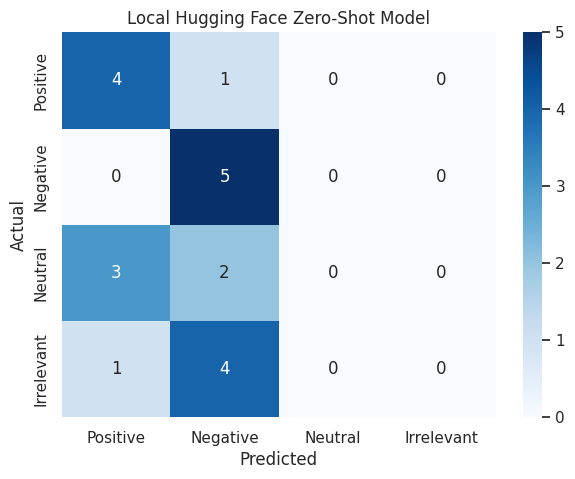

In [24]:
print(classification_report(hf_sample["sentiment"], hf_sample["hf_prediction"], labels=LABELS))
show_confusion_matrix(hf_sample["sentiment"], hf_sample["hf_prediction"], "Local Hugging Face Zero-Shot Model")

hf_metrics = {
    "method": "Local Hugging Face zero-shot",
    "model": HF_MODEL_NAME,
    "accuracy": accuracy_score(hf_sample["sentiment"], hf_sample["hf_prediction"]),
    "macro_f1": f1_score(hf_sample["sentiment"], hf_sample["hf_prediction"], labels=LABELS, average="macro"),
    "weighted_f1": f1_score(hf_sample["sentiment"], hf_sample["hf_prediction"], labels=LABELS, average="weighted"),
    "runtime_seconds": hf_runtime,
}

## 12. Final Comparison Table

In [25]:
traditional_best_metrics = best_row.to_dict()
traditional_best_metrics["notes"] = "Trained and tested on the full validation set."

hf_metrics["notes"] = f"Tested on a small balanced sample of {len(hf_sample)} tweets because zero-shot models are slower."

comparison_df = pd.DataFrame([traditional_best_metrics, hf_metrics])
comparison_df[["method", "model", "accuracy", "macro_f1", "weighted_f1", "runtime_seconds", "notes"]]

,method,model,accuracy,macro_f1,weighted_f1,runtime_seconds,notes
0,Traditional TF-IDF,Stemmed text + Linear SVM,0.983,0.981971,0.983046,6.906097,Trained and tested on the full validation set.
1,Local Hugging Face zero-shot,facebook/bart-large-mnli,0.450,0.300905,0.300905,96.398803,Tested on a small balanced sample of 20 tweets...


## 13. Try the Saved Traditional Model

In [26]:
loaded_package = joblib.load(model_path)
loaded_model = loaded_package["model"]
loaded_text_method = loaded_package["text_method"]

new_tweets = [
    "I love this game. The new update is amazing!",
    "This service is terrible and keeps crashing.",
    "The product page was updated today.",
    "I made lunch while everyone was talking about the match.",
]

clean_new_tweets = [clean_tweet(tweet, method=loaded_text_method) for tweet in new_tweets]
new_predictions = loaded_model.predict(clean_new_tweets)

pd.DataFrame({"tweet": new_tweets, "prediction": new_predictions})

,tweet,prediction
0,I love this game. The new update is amazing!,Positive
1,This service is terrible and keeps crashing.,Negative
2,The product page was updated today.,Irrelevant
3,I made lunch while everyone was talking about ...,Neutral
